# Hylight

In [1]:
import hylightpy

In [20]:
from matplotlib import pyplot as plt
import numpy as np

In [2]:
hylightpy.__version__

'0.0.17'

First, we initialise the class with a 10-level atom in Case B, enabling radiative recombination only (i.e. shutting down collisional excitation from the ground states). 

Here, we use 100 levels for demonstration. The user should caution that this is a memory-intensive caculation. Be careful to run the code on your personal laptop! 

**Note: Initialising H atom with 100 levels takes 16 GB RAM and 1000 seconds.**

**Note: Initialising H atom with 10 levels takes 10 GB RAM and 1000 seconds.**

The following line will create a cache directory in your working directory. There is the optional to point to a user-defined path. 

We use a cache folder to store the cascade matrix elements so that we don't need to compute them everytime. 

In [3]:
HI = hylightpy.HIAtom(nmax = 100, verbose=True, caseB=True,
                        recom=True, coll=False, cache_path='/cosma/home/dp004/dc-liu3/snap7/sims/cache')

print("Class initialized")

 ░▒▓█▓▒░░▒▓█▓▒░▒▓█▓▒░░▒▓█▓▒░▒▓█▓▒░      ░▒▓█▓▒░░▒▓██████▓▒░░▒▓█▓▒░░▒▓█▓▒░▒▓████████▓▒░ 
 ░▒▓█▓▒░░▒▓█▓▒░▒▓█▓▒░░▒▓█▓▒░▒▓█▓▒░      ░▒▓█▓▒░▒▓█▓▒░░▒▓█▓▒░▒▓█▓▒░░▒▓█▓▒░  ░▒▓█▓▒░     
 ░▒▓█▓▒░░▒▓█▓▒░▒▓█▓▒░░▒▓█▓▒░▒▓█▓▒░      ░▒▓█▓▒░▒▓█▓▒░      ░▒▓█▓▒░░▒▓█▓▒░  ░▒▓█▓▒░     
 ░▒▓████████▓▒░░▒▓██████▓▒░░▒▓█▓▒░      ░▒▓█▓▒░▒▓█▓▒▒▓███▓▒░▒▓████████▓▒░  ░▒▓█▓▒░     
 ░▒▓█▓▒░░▒▓█▓▒░  ░▒▓█▓▒░   ░▒▓█▓▒░      ░▒▓█▓▒░▒▓█▓▒░░▒▓█▓▒░▒▓█▓▒░░▒▓█▓▒░  ░▒▓█▓▒░     
 ░▒▓█▓▒░░▒▓█▓▒░  ░▒▓█▓▒░   ░▒▓█▓▒░      ░▒▓█▓▒░▒▓█▓▒░░▒▓█▓▒░▒▓█▓▒░░▒▓█▓▒░  ░▒▓█▓▒░     
 ░▒▓█▓▒░░▒▓█▓▒░  ░▒▓█▓▒░   ░▒▓████████▓▒░▒▓█▓▒░░▒▓██████▓▒░░▒▓█▓▒░░▒▓█▓▒░  ░▒▓█▓▒░     
Folder '/cosma/home/dp004/dc-liu3/snap7/sims/cache' already exists.
Einstein coefficients unpickled from existing file
 ... Imposing caseB (no Lyman-transitions) 
Recombination rates read and fitted
Collisional Excitaion Rates read and fitted
Cascade matrix coefficients unpickled
Cascade matrix class initialized 
Class initialized


We storeed the Einstein $A$ coefficients in the class. They can be viewed using the following line, where we use the ($n$,$l$) to denote the atomic states. 

In [4]:
# Einstein coefficients correponding to 3p -> 2s transition
HI.A[(3,1)][(2,0)]

np.float64(22436400.0)

Note that in Case~B, the Lyman transitions are optically thick, hence we force the Einstein $A$ values of the Lyman transitions to be zero. 

In [5]:
# Einstein coefficients correponding to 2p -> 1s transition, 0 in Case B
HI.A[(2,1)][(1,0)]

0.0

## Line emissivity

The user specifies the electron density, HI and HII density as well as the temperature and the transition they are intersted in. 
In the following example, we set the electron density and HII density to 100 cm$^{-3}$ and the HI density to 10$^{-5}$ cm$^{-3}$. As an example, we calculate the 3$\to$ 2 transition (Balmer $\alpha$) at 10$^4$ K. 

All units are in CGS, i.e. density in cm$^{-3}$. We utilise the unyt package to ensure the units are correct. 

In [6]:
import unyt

In [7]:
HI.get_emissivity(ne=unyt.array.unyt_array([1e2], 'cm**(-3)'),
                  nHII=unyt.array.unyt_array([1e2], 'cm**(-3)'),
                  nHI=unyt.array.unyt_array([1e-5], 'cm**(-3)'),
                  temp=unyt.array.unyt_array([1e4], 'K'),
                  nupper=3, nlower=2)

unyt_array([3.50935979e-21], 'erg/(cm**3*s)')

The emissivity actually scales nicely with $n_e n_p$ (see Liu et al. 2025). See the following example. For a given temperature, we vary the density of hydrogen gas and assume the gas is fully ionised ($n_e \approx n_p$). 

In [34]:
ne   = [1e-1, 1e0, 1e1, 1e2, 1e3] * unyt.unyt_array(1, 'cm**(-3)')
nHII = [1e-1, 1e0, 1e1, 1e2, 1e3] * unyt.unyt_array(1, 'cm**(-3)')
nHI  = [1e-5, 1e-5, 1e-5, 1e-5, 1e-5] * unyt.unyt_array(1, 'cm**(-3)')
temp = [1e4, 1e4, 1e4, 1e4, 1e4] * unyt.unyt_array(1, 'K')

eps  = np.zeros(len(ne))
eps  = HI.get_emissivity(ne=ne, nHII=nHII,
                         nHI=nHI,
                         temp=temp,
                         nupper=3, nlower=2)

eps_scaling = eps / (ne * nHII)

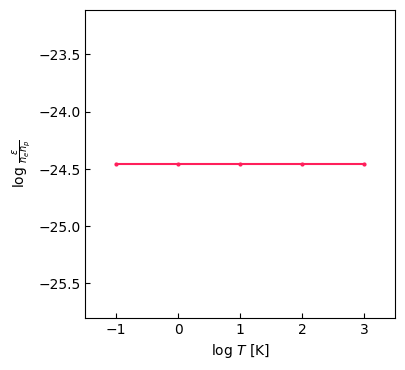

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax.plot(np.log10(ne.value), np.log10(eps_scaling), color='#FF1F5B', marker='o', linestyle='-', markersize=2)

ax.set_yscale('linear')
ax.set_xscale('linear')
ax.set_xlabel(r'log $T$ [K]')
ax.set_ylabel(r'log $\frac{\epsilon}{n_e n_p}$')
ax.set_xlim(-1.5, 3.5)
ax.tick_params(axis="y",direction="in")
ax.tick_params(axis="x",direction="in")

In the following plot, we plot the emissivity (scaled by $n_e n_p$) as a function of temperature. The temperature dependence in this case comes largely from the weak dependence of recombination coeffcient on temperature. 

In [37]:
ne   = [1e2, 1e2, 1e2, 1e2, 1e2, 1e2] * unyt.unyt_array(1, 'cm**(-3)')
nHII = [1e2, 1e2, 1e2, 1e2, 1e2, 1e2] * unyt.unyt_array(1, 'cm**(-3)')
nHI  = [1e-5, 1e-5, 1e-5, 1e-5, 1e-5, 1e-5] * unyt.unyt_array(1, 'cm**(-3)')
temp = [1e2, 10**(2.5), 1e3, 10**(3.5), 1e4, 10**(4.5)] * unyt.unyt_array(1, 'K')

eps  = np.zeros(len(ne))
eps  = HI.get_emissivity(ne=ne, nHII=nHII,
                         nHI=nHI,
                         temp=temp,
                         nupper=3, nlower=2)

eps_scaling = eps / (ne * nHII)

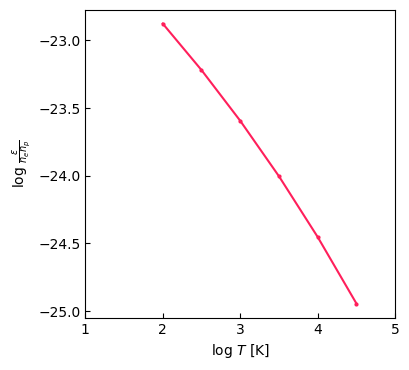

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax.plot(np.log10(temp.value), np.log10(eps_scaling), color='#FF1F5B', marker='o', linestyle='-', markersize=2)

ax.set_yscale('linear')
ax.set_xscale('linear')
ax.set_xlabel(r'log $T$ [K]')
ax.set_ylabel(r'log $\frac{\epsilon}{n_e n_p}$')
ax.set_xlim(1, 5)
ax.tick_params(axis="y",direction="in")
ax.tick_params(axis="x",direction="in")

## Level population for a specific state

The user specifies the electron density, HI and HII density as well as the temperature and the specific state they are intersted in. 
In the following example, we set the electron density and HII density to 100 cm$^{-3}$ and the HI density to 10$^{-5}$ cm$^{-3}$. As an example, we calculate the 3$s$ level population density at 10$^4$ K. 

All units are in CGS, i.e. density in cm$^{-3}$. 

In [42]:
levelpop_3s = HI.compute_level_pop(ne=unyt.array.unyt_array([1e2], 'cm**(-3)'), 
                                   nHI=unyt.array.unyt_array([1e-5], 'cm**(-3)'),
                                   nHII=unyt.array.unyt_array([1e2], 'cm**(-3)'), 
                                   temp=unyt.array.unyt_array([1e4], 'K'), 
                                   n=3, l=0)
print(levelpop_3s)

[2.42094978e-17]


### Temperature dependence of the level population

We demonstrate the temperature dependence of level popualtion 3$s$ in the following example. 

In [43]:
n = 3
l = 0
logT_list = [1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5]
levelpop = np.zeros_like(logT_list, dtype=float)
for i, logT in enumerate(logT_list):
    levelpop[i] = HI.compute_level_pop(ne=unyt.array.unyt_array([1e2], 'cm**(-3)'), 
                                       nHI=unyt.array.unyt_array([1e2], 'cm**(-3)'),
                                       nHII=unyt.array.unyt_array([1e2], 'cm**(-3)'), 
                                       temp=unyt.array.unyt_array([10**logT], 'K'), 
                                       n=3, l=0)

/tmp/ipykernel_582462/3466169637.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  levelpop[i] = HI.compute_level_pop(ne=unyt.array.unyt_array([1e2], 'cm**(-3)'),


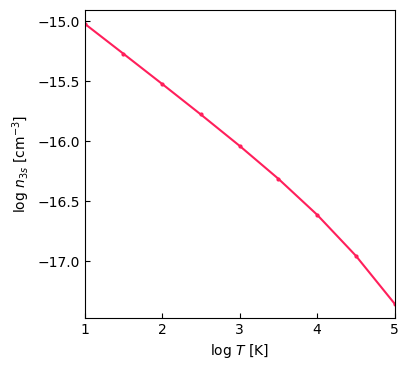

In [44]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax.plot(logT_list, np.log10(levelpop), color='#FF1F5B', marker='o', linestyle='-', markersize=2)

ax.set_yscale('linear')
ax.set_xscale('linear')
ax.set_xlabel(r'log $T$ [K]')
ax.set_ylabel(r'log $n_{3s}$ [cm$^{-3}$]')
ax.set_xlim(1, 5)
ax.tick_params(axis="y",direction="in")
ax.tick_params(axis="x",direction="in")

## Recombination rate coefficients

In [45]:
import importlib

In [46]:
fpath = importlib.resources.files('hylightpy.data').joinpath('h_iso_recomb_HI_150.dat')
recom_dict = HI.read_recombination_rates(fname=fpath)

In [47]:
logTs = recom_dict['LogTs']
alpha_nl = recom_dict['recom_data']

### Temperature-dependence of the total recombination rate coefficent

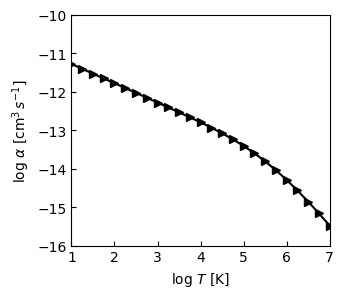

In [48]:
fig, ax = plt.subplots(1, 1, figsize=(10/3, 3))

# index 0 gives the total recombination rate
ax.plot(logTs, alpha_nl.iloc[0, 2: 43], color='k', linestyle='-', marker='>')


ax.set_yscale('linear')
ax.set_xscale('linear')
ax.set_xlabel(r'log $T$ [K]')
ax.set_ylabel(r'log $\alpha$ [cm$^{3} \, s^{-1}$]')
ax.set_xlim(1, 7)
ax.set_ylim(-16, -10)
ax.tick_params(axis="y",direction="in")
ax.tick_params(axis="x",direction="in")

### Temperature-dependence of the recombination rate coefficent of a specific state

The followng function calculates the index of a specific level in the recombination table. 

In [49]:
def get_l_level_index(n=1, l=0):
    assert type(n) == int and type(l) == int, 'n and l must be intergers.'
    assert n >= 1, 'Princuple quantum number can not be smaller than 1.'
    assert l < n and l >= 0, 'Angular momentum must be positive and smalled than principle quantum number.'
    
    il = 0
    for j in np.arange(1, n):
        il = il + j 
    il = il + l + 1 # count the l level at current n level, l start from 0
    
    return il

For example, for level 3$s$, the index is 4:

In [50]:
get_l_level_index(n=3, l=0)

np.int64(4)

Hence, the temperature-dependence of the recombination rate coefficient $\alpha_{3,0}$ looks like:

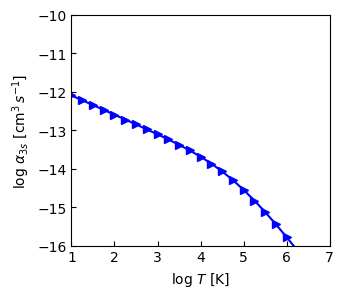

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(10/3, 3))

# index 4 gives alpha_{3s}
ax.plot(logTs, alpha_nl.iloc[4, 2: 43], color='blue', linestyle='-', marker='>')


ax.set_yscale('linear')
ax.set_xscale('linear')
ax.set_xlabel(r'log $T$ [K]')
ax.set_ylabel(r'log $\alpha_{3s}$ [cm$^{3} \, s^{-1}$]')
ax.set_xlim(1, 7)
ax.set_ylim(-16, -10)
ax.tick_params(axis="y",direction="in")
ax.tick_params(axis="x",direction="in")